Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Compiling model...
'compile' took 0.767360 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [4.02e+00, 9.08e-04, 1.60e+01]    [4.00e+00, 9.08e-04, 1.60e+01]    [1.01e+00]    


/home/hridoy/miniconda3/envs/torch-env/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [7.60e-04, 3.33e-08, 4.92e-08]    [6.24e-04, 3.34e-08, 4.92e-08]    [1.56e-03]    
2000      [5.43e-05, 5.67e-10, 8.74e-10]    [4.05e-05, 5.61e-10, 8.74e-10]    [7.28e-04]    
3000      [8.17e-06, 3.14e-09, 2.65e-09]    [8.81e-06, 3.11e-09, 2.58e-09]    [3.57e-04]    
4000      [5.04e-06, 8.86e-07, 7.20e-07]    [5.75e-06, 8.87e-07, 7.20e-07]    [3.70e-04]    
5000      [8.88e-05, 9.93e-04, 8.10e-04]    [9.26e-05, 9.93e-04, 8.10e-04]    [1.05e-02]    
6000      [1.64e-06, 2.84e-12, 1.46e-11]    [2.14e-06, 1.84e-12, 1.84e-11]    [2.23e-04]    
7000      [4.12e-05, 3.56e-04, 3.38e-04]    [4.42e-05, 3.56e-04, 3.38e-04]    [6.42e-03]    
8000      [7.16e-07, 2.31e-10, 2.26e-10]    [1.15e-06, 2.26e-10, 2.26e-10]    [1.56e-04]    
9000      [7.00e-07, 5.51e-07, 4.84e-07]    [1.07e-06, 5.51e-07, 4.84e-07]    [2.36e-04]    
10000     [6.01e-07, 5.21e-11, 5.12e-11]    [1.09e-06, 4.98e-11, 5.12e-11]    [1.41e-04]    

Best model at step 10000:
  train loss: 6.01e-07
  test loss: 1.09e-0

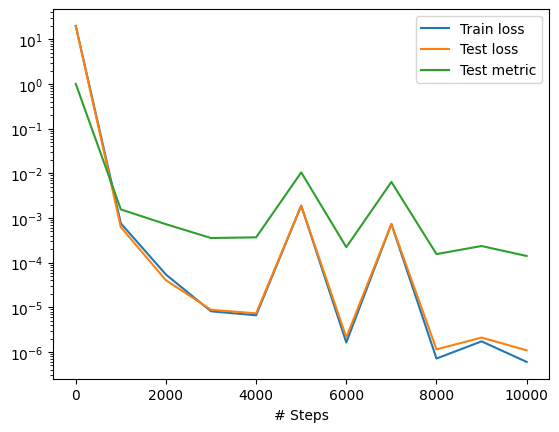

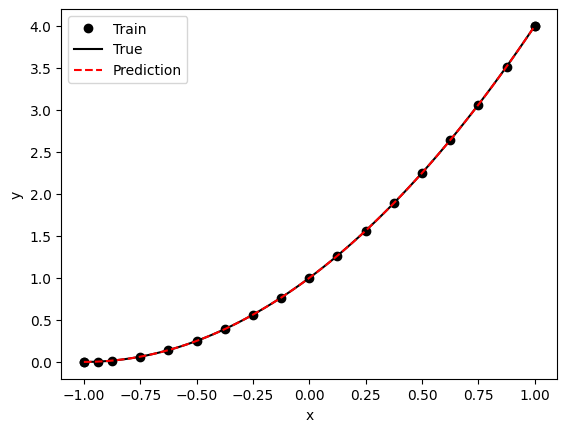

In [1]:
import deepxde as dde
import numpy as np

def pde(x, y):
    dy_xx = dde.grad.hessian(y, x)

    return dy_xx - 2

def boundary_l(x, on_boundary):       # left boundary
    return on_boundary and dde.utils.isclose(x[0], -1)

def boundary_r(x, on_boundary):       # right boundary
    return on_boundary and dde.utils.isclose(x[0], 1)

def func(x):
    return (x + 1) ** 2

geom = dde.geometry.Interval(-1, 1)
bc_l = dde.icbc.DirichletBC(geom, func, boundary_l)
bc_r = dde.icbc.NeumannBC(geom, lambda X: 2 * (X + 1), boundary_r)
data = dde.data.PDE(geom, pde, [bc_l, bc_r], 16, 2, solution=func, num_test=100)

layer_size = [1] + [50] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=10000)

dde.saveplot(losshistory, train_state, issave=False, isplot=True)